In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
df_full = pd.read_csv("mi_full_km.csv")
# df_full = pd.read_csv("mi_full_wd.csv")
# df_full = pd.read_csv("mi_full.csv")
df_full.head()

,dataset,model,layer,method,value,speaker
0,timit,hubert-large-en,0,km_2_mi,0.011203,True
1,timit,hubert-large-en,0,km_4_mi,0.030799,True
2,timit,hubert-large-en,0,km_8_mi,0.211242,True
3,timit,hubert-large-en,0,km_16_mi,0.374564,True
4,timit,hubert-large-en,0,km_32_mi,0.554207,True


(-0.3, 3.564505872744928)

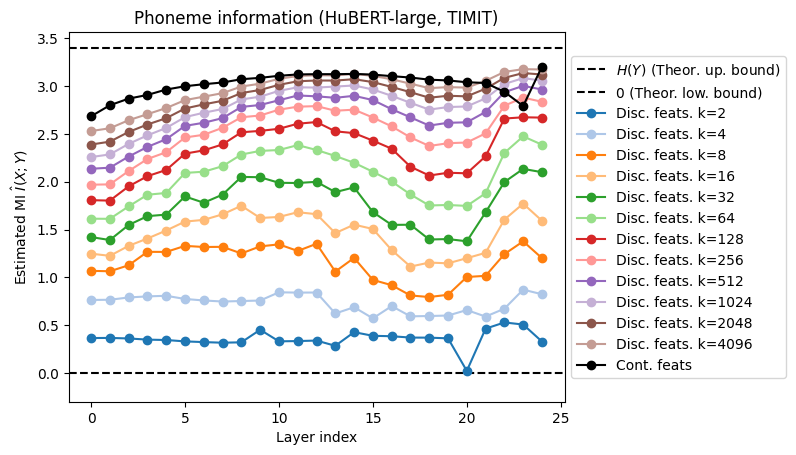

In [24]:
speaker = False
df = df_full[df_full.speaker == speaker]
plt.axhline(y=df[df.method == "entropy"].iloc[0].value, linestyle="--", label=r"$H(Y)$ (Theor. up. bound)", c="black")
plt.axhline(y=0, linestyle="--", c="black", label="0 (Theor. low. bound)")

cmap = plt.get_cmap('tab20')
for i, k in enumerate((2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096)):
    plt.plot(df[df.method == f"km_{k}_mi"].sort_values("layer").value.to_numpy(), "o-", label=f"Disc. feats. k={k}", color=cmap(i))
plt.plot(df[df.method == "clf_mi"].sort_values("layer").value.to_numpy(), "o-", label="Cont. feats", c="black")
# if speaker:
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.xlabel("Layer index")
plt.ylabel("Estimated MI " + r"$\hat{I}(X;Y)$")
plt.title(f"{'Speaker' if speaker else 'Phoneme'} information (HuBERT-large, TIMIT)")
plt.ylim(-0.3)
# plt.savefig(f"plots/{'Speaker' if speaker else 'Phoneme'}.pdf", bbox_inches="tight")

Using GPU for kmeans


In [18]:
%load_ext autoreload
%autoreload 2

from mutual_info import get_clf_mi, _prepare_data, get_kmeans_mi
import pandas as pd
dataset, model, layer, label_type = "timit", "hubert-large-en", 24, "random"
df = pd.read_pickle(f"data/{dataset}-{model}-{layer}.pkl")
train_x, train_y, test_x, test_y = _prepare_data(df, label_type=label_type)
# get_clf_mi(train_x, train_y, test_x, test_y, verbose=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
from mutual_info import get_entropy
get_entropy(test_y), get_kmeans_mi(train_x, test_x, test_y, n_clusters=2048)

(2.3024706106327133, 0.19626737367589328)